## Import libraries

In [2]:
import pandas  as pd
import seaborn as sns
import os
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams['text.usetex'] = True
plt.rcParams['text.usetex'] = True

def start_plot(figsize=(10, 8), style = 'whitegrid', dpi=100):
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(1,1)
    plt.tight_layout()
    with sns.axes_style(style):
        ax = fig.add_subplot(gs[0,0])
    return fig, ax

In [96]:
# Try reading with 'big5' encoding which is common for Traditional Chinese Windows systems
# If this fails, try 'cp1252' or 'latin1'
df = pd.read_csv("D:\\SEM\\Emily隔膜分析1229\\sem_analysis_log.csv", encoding='big5')
df_206 = df.loc[df["CELL"] == 206]
df_206[["porosity", "mean_pore_size"]] = df_206[["porosity", "mean_pore_size"]].apply(lambda x: round(x, 2))
B_10000_206 = df_206.loc[(df_206["倍率"]==10000) & (df_206["面"]=="B")]["mean_pore_size"].mean()
B_5000_206 = df_206.loc[(df_206["倍率"]==5000) & (df_206["面"]=="B")]["mean_pore_size"].mean()
A_10000_206 = df_206.loc[(df_206["倍率"]==10000) & (df_206["面"]=="A")]["mean_pore_size"].mean()
A_5000_206 = df_206.loc[(df_206["倍率"]==5000) & (df_206["面"]=="A")]["mean_pore_size"].mean()

C:\Users\AnalyzeLab\AppData\Local\Temp\ipykernel_64124\1139096056.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_206[["porosity", "mean_pore_size"]] = df_206[["porosity", "mean_pore_size"]].apply(lambda x: round(x, 2))


In [1]:
FOV_10000 = 12.7
pixels_width = 1280
scale_10000 = FOV_10000 / pixels_width  
FOV_5000 = 63.5
pixels_width = 1280
scale_5000 = FOV_5000 / pixels_width  

In [2]:
scale_5000, scale_10000

(0.049609375, 0.009921875)

In [99]:
(B_10000_206 * (scale_10000**2) + B_5000_206 * (scale_5000**2)) / 2

0.029483859252929692

In [88]:
((196.07999999999996) * (0.009921875**2) + 100.63 * (0.01984375**2)) / 2

0.02946417053222656

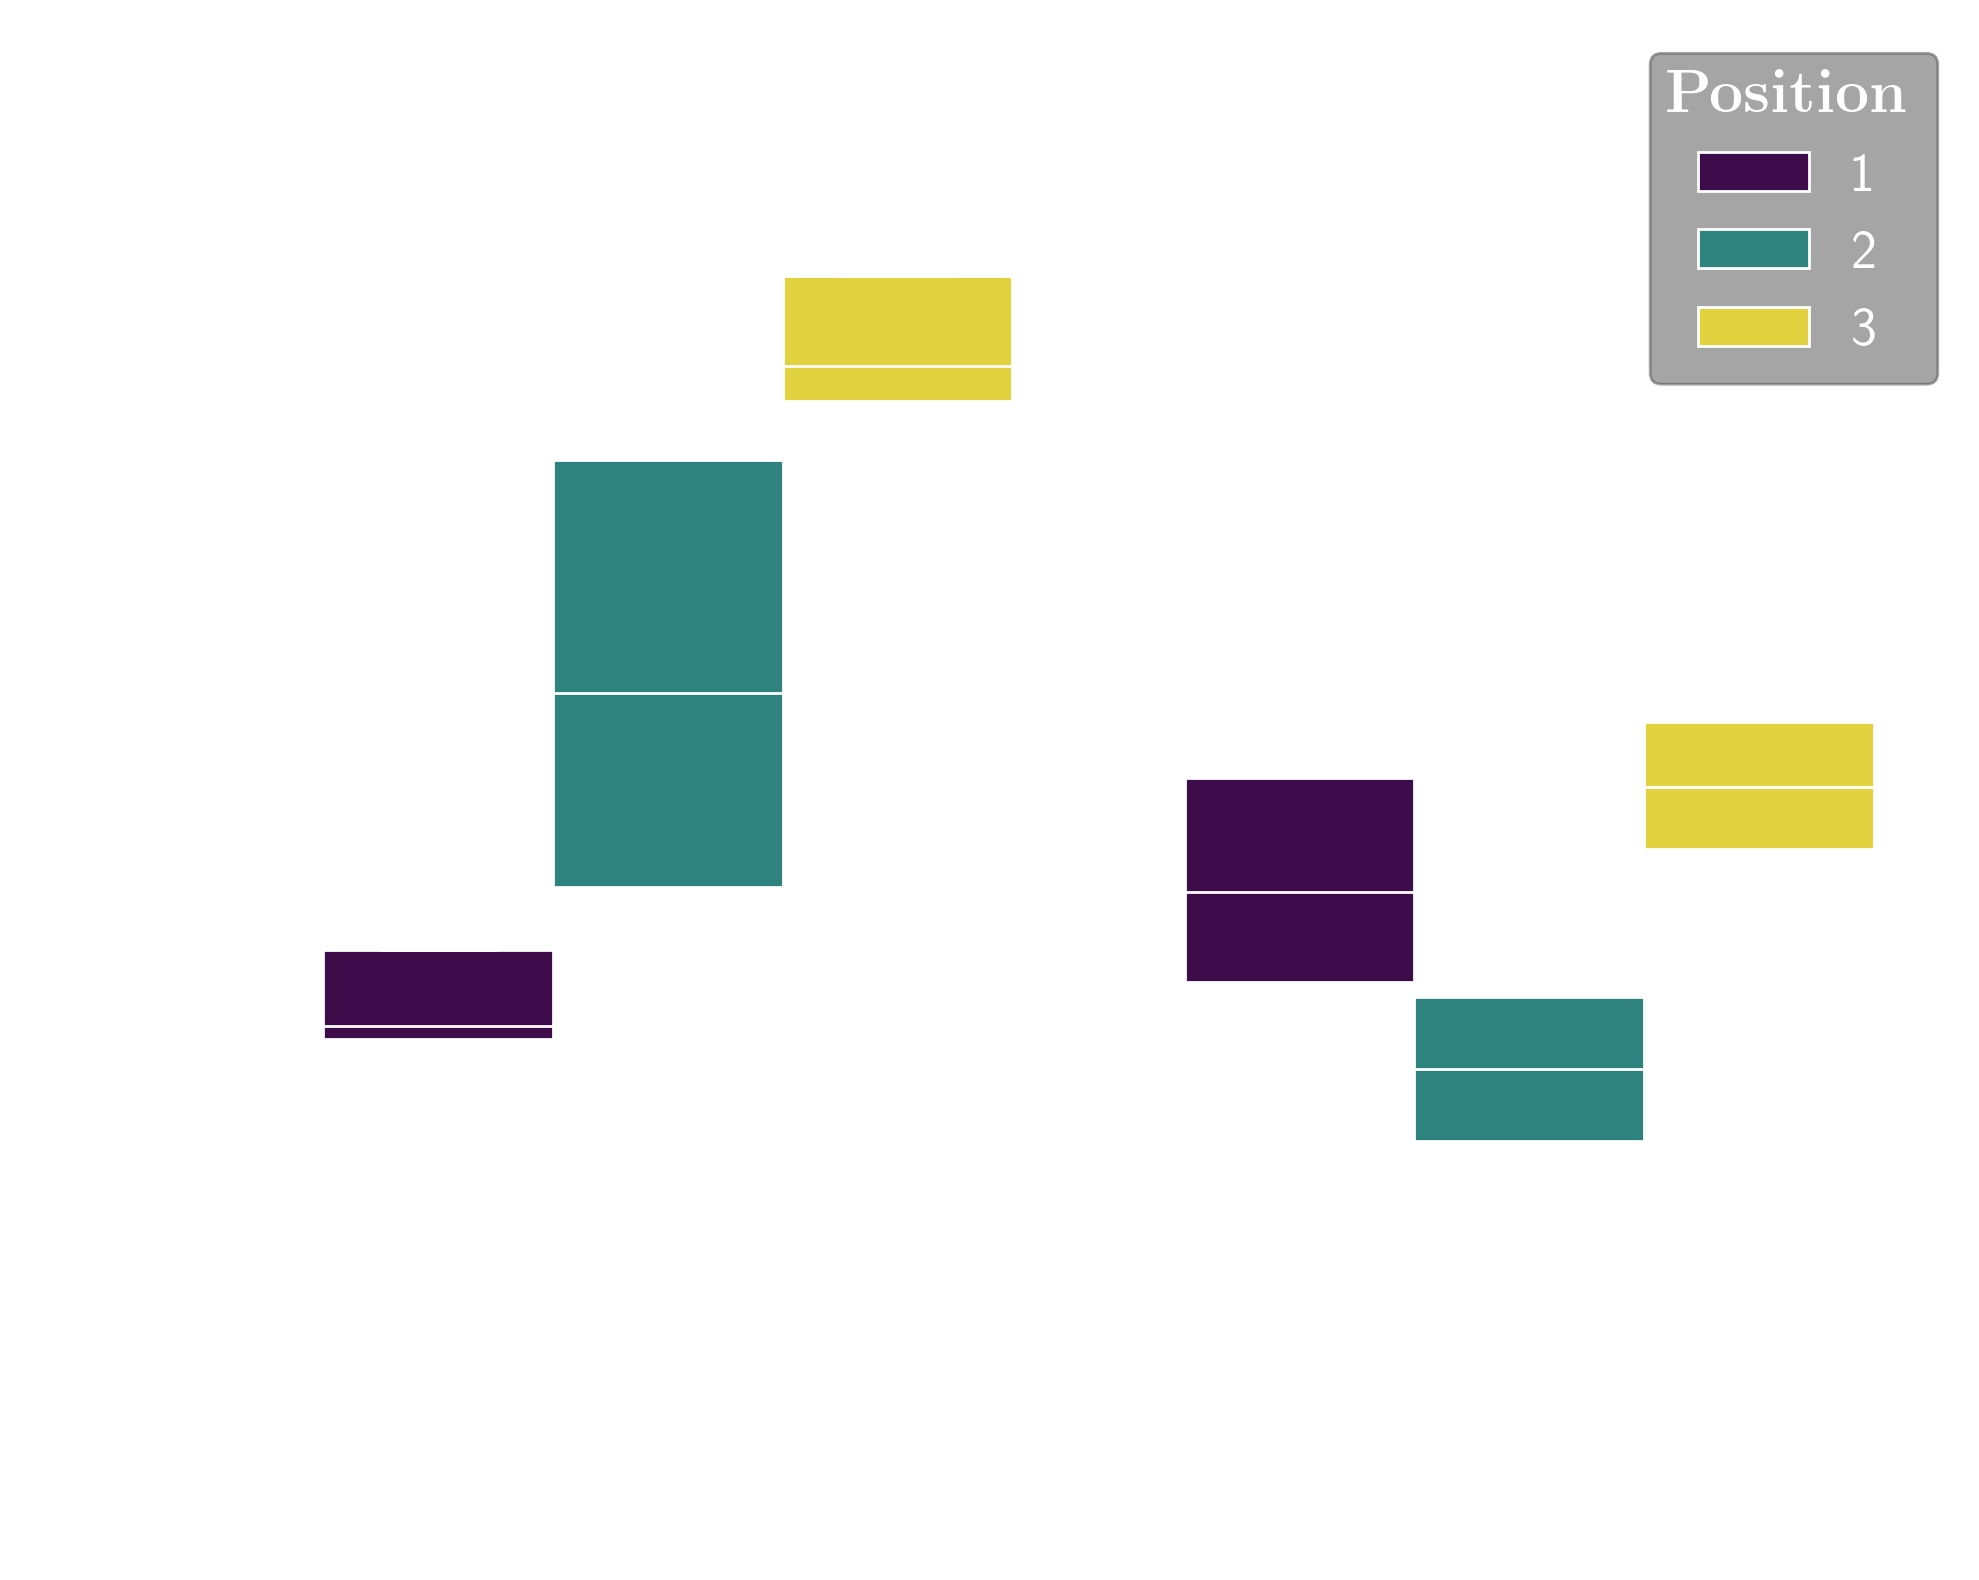

In [50]:
fig, ax = start_plot(figsize=(10, 8), style='darkgrid', dpi=200)
fig.patch.set_alpha(0.0)  # Make figure background transparent
ax.patch.set_alpha(0.0)   # Make axes background transparent
sns.boxplot(data=df, x='CELL', y='porosity', palette="viridis", ax=ax, hue="位置", linecolor="white")
plt.xlabel(rf'$\bf Cell$',  fontsize=40, color='white')
plt.ylabel(rf'$\bf Porosity(\%)$',  fontsize=40, color='white')
plt.xticks(fontsize=30, color='white')
plt.yticks(fontsize=30, color='white')

ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)  # Ensure grid is behind the plot

legend = ax.legend(fontsize=20, title=rf"$\bf Position$", title_fontsize=22, 
          loc='upper right', shadow=True, framealpha=0.0, labelcolor="white")  # Make legend background transparent
legend.get_title().set_color("white")

plt.tight_layout()
plt.show()

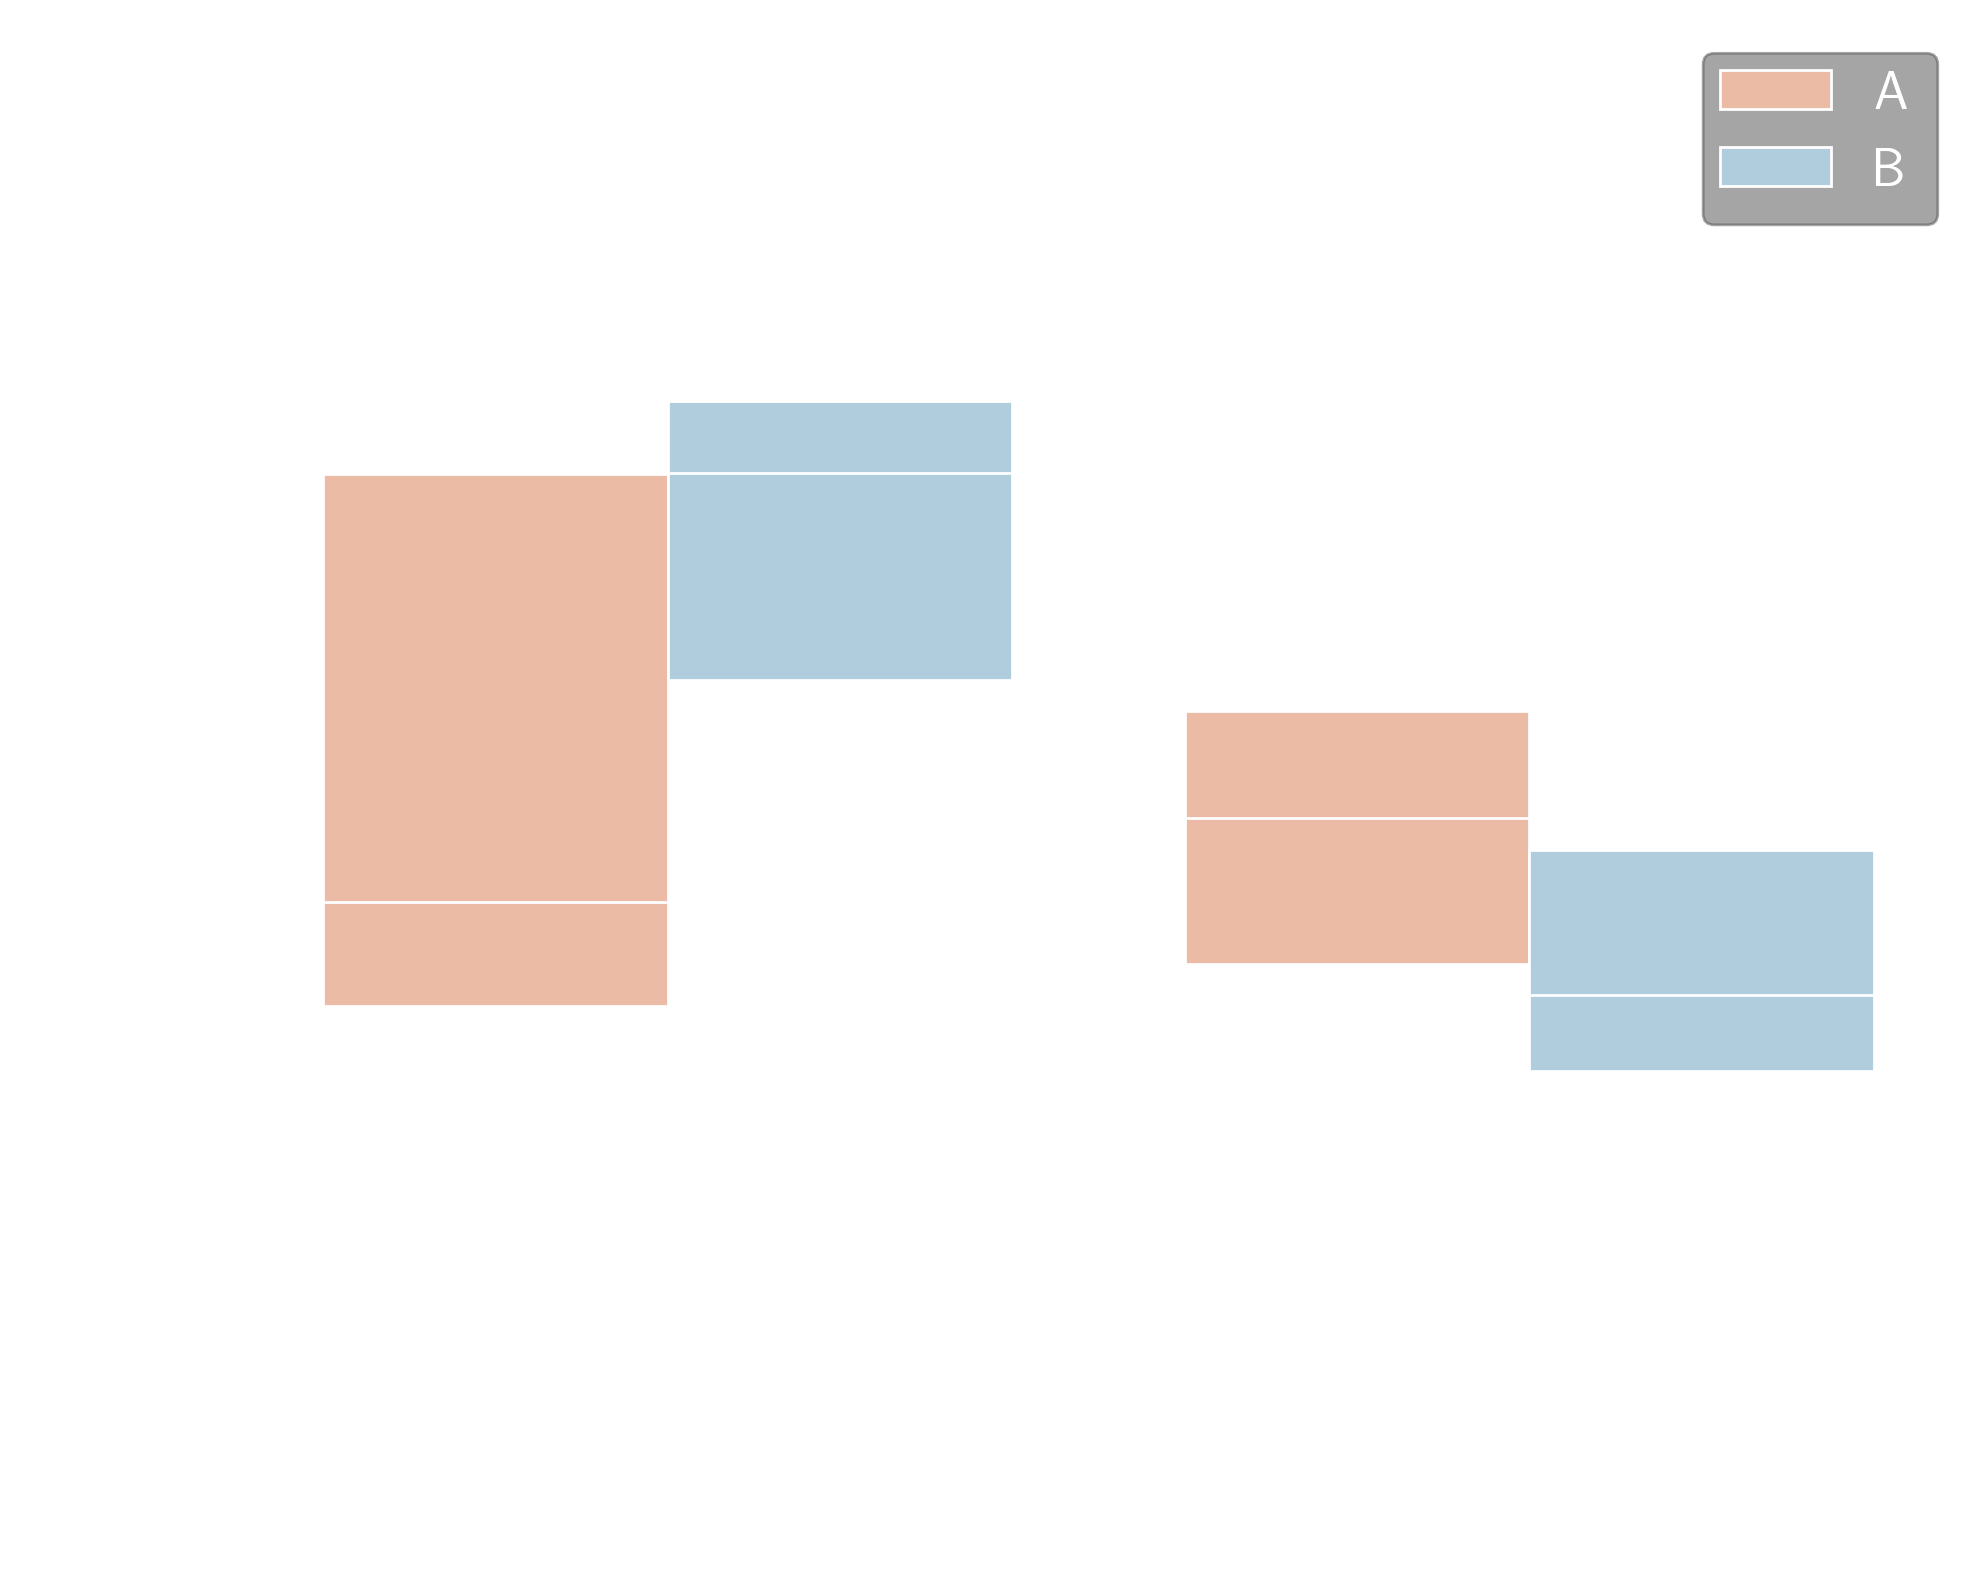

In [51]:
fig, ax = start_plot(figsize=(10, 8), style='darkgrid', dpi=200)
fig.patch.set_alpha(0.0)  # Make figure background transparent
ax.patch.set_alpha(0.0)   # Make axes background transparent
sns.boxplot(data=df, x='CELL', y='porosity', palette="RdBu", ax=ax, hue="面", linecolor="white")
plt.xlabel(rf'$\bf Cell$',  fontsize=40, color='white')
plt.ylabel(rf'$\bf Porosity(\%)$',  fontsize=40, color='white')
plt.xticks(fontsize=30, color='white')
plt.yticks(fontsize=30, color='white')

ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)  # Ensure grid is behind the plot

legend = ax.legend(fontsize=20, title_fontsize=22, 
          loc='upper right', shadow=True, framealpha=0.0, labelcolor="white")  # Make legend background transparent
legend.get_title().set_color("white")

plt.tight_layout()
plt.show()

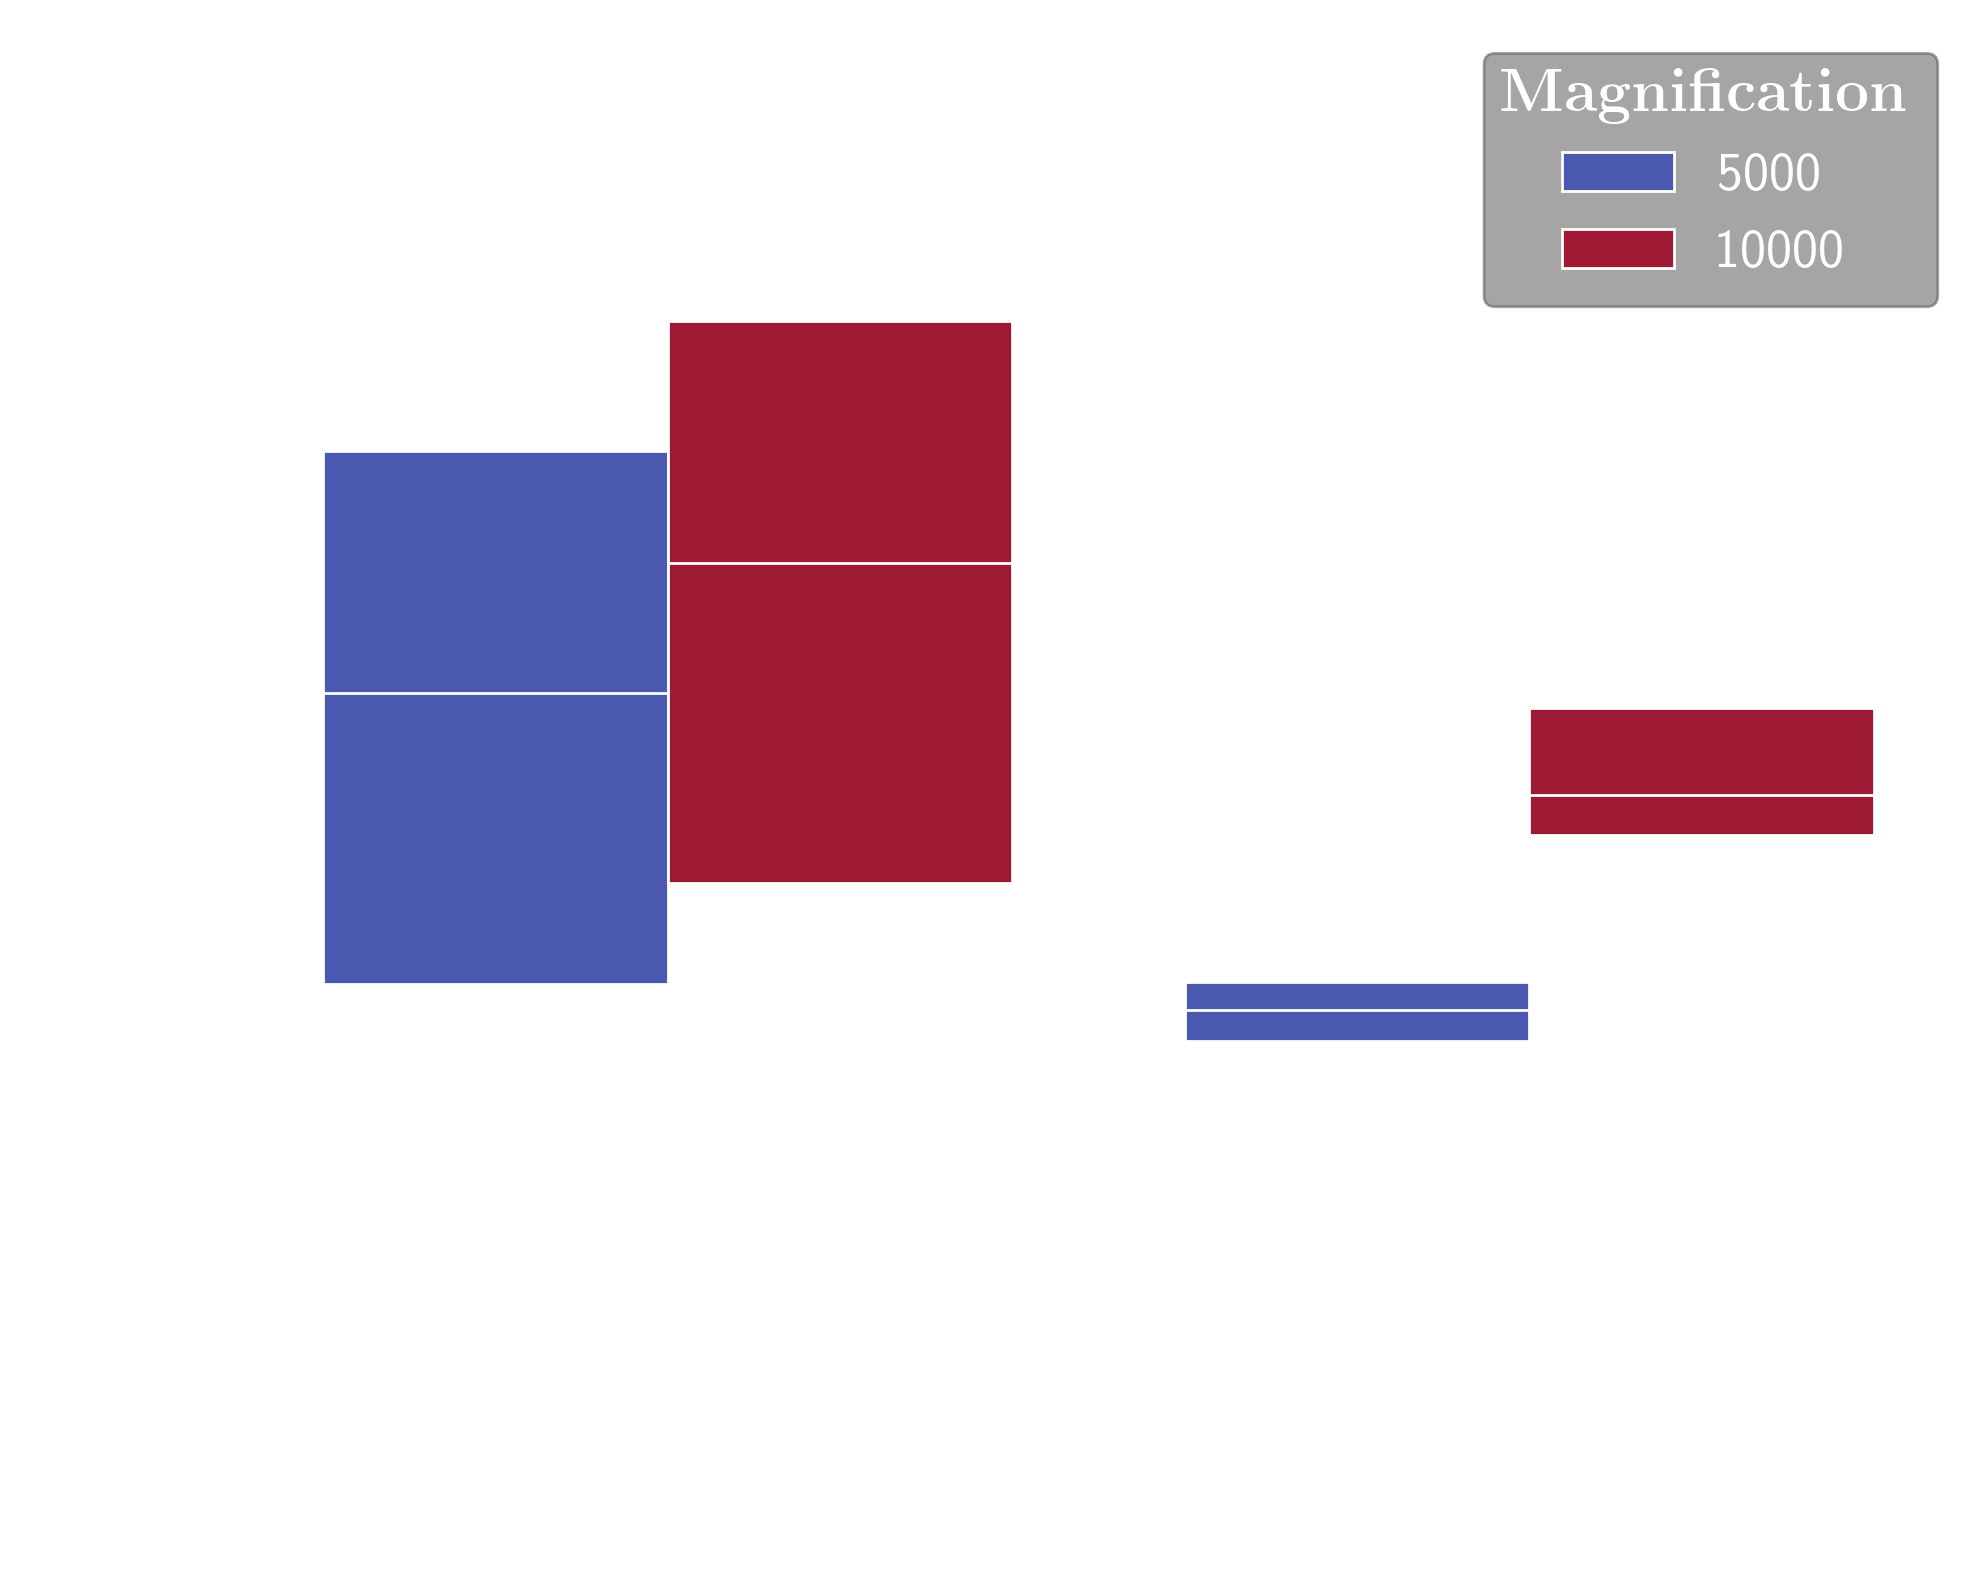

In [52]:
fig, ax = start_plot(figsize=(10, 8), style='darkgrid', dpi=200)
fig.patch.set_alpha(0.0)  # Make figure background transparent
ax.patch.set_alpha(0.0)   # Make axes background transparent
sns.boxplot(data=df, x='CELL', y='porosity', palette="coolwarm", ax=ax, hue="倍率", linecolor="white")
plt.xlabel(rf'$\bf Cell$',  fontsize=40, color='white')
plt.ylabel(rf'$\bf Porosity(\%)$',  fontsize=40, color='white')
plt.xticks(fontsize=30, color='white')
plt.yticks(fontsize=30, color='white')

ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)  # Ensure grid is behind the plot

legend = ax.legend(fontsize=20, title_fontsize=22, title=rf"$\bf Magnification$",
          loc='upper right', shadow=True, framealpha=0.0, labelcolor="white")  # Make legend background transparent
legend.get_title().set_color("white")

plt.tight_layout()
plt.show()

C:\Users\AnalyzeLab\AppData\Local\Temp\ipykernel_45204\2979290459.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Position"].replace({"Top": rf"$\bf Top$",


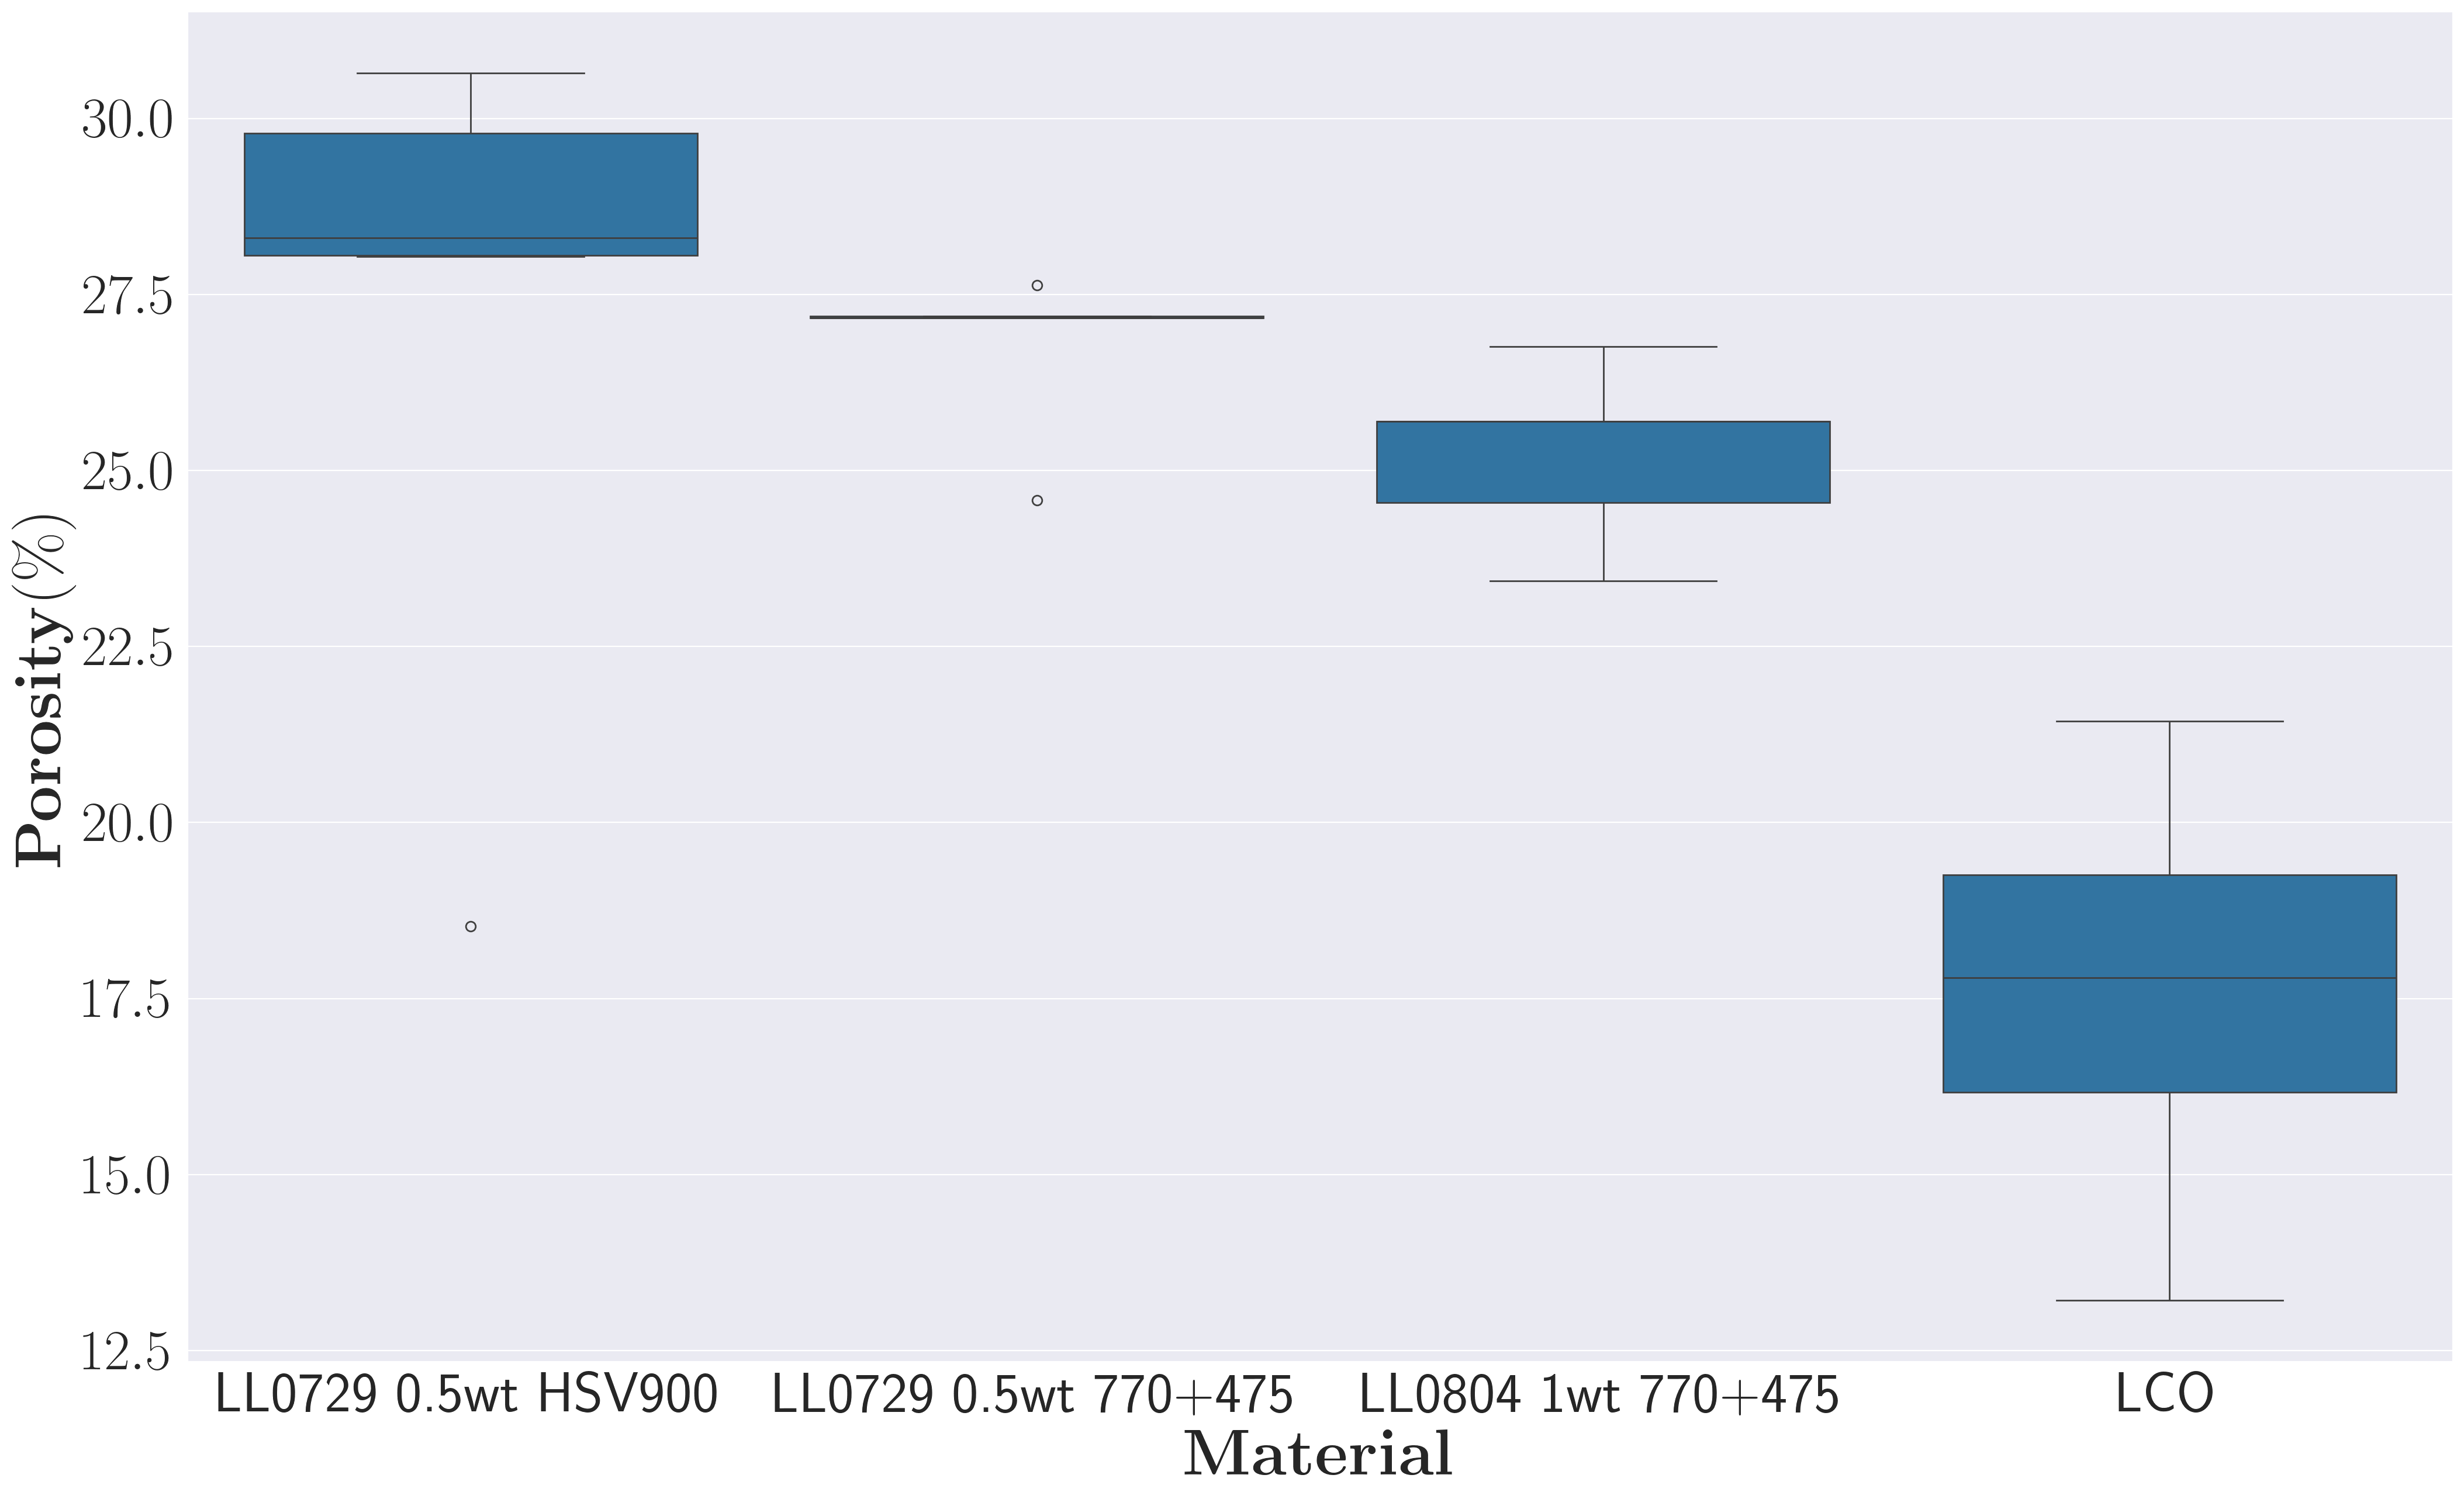

In [31]:
ax = start_plot(style="darkgrid", dpi=200, figsize=(25, 15))

df = meta_df.copy()
df["Position"].replace({"Top": rf"$\bf Top$", 
                        "top": rf"$\bf Top$", 
                         "Cross": rf"$\bf Cross$"}, inplace=True)
sns.boxplot(data=df, x="Material", y="porosity", gap=2)

plt.ylabel(rf"$\bf Porosity (\%)$", fontsize=40)
plt.xlabel(rf"$\bf Material $", fontsize=40)
plt.yticks(fontsize=35)
plt.xticks(fontsize=35)
# ax.legend(title=rf"$\bf Detector$", shadow=True, fontsize=15)
plt.show()

### Magnitude

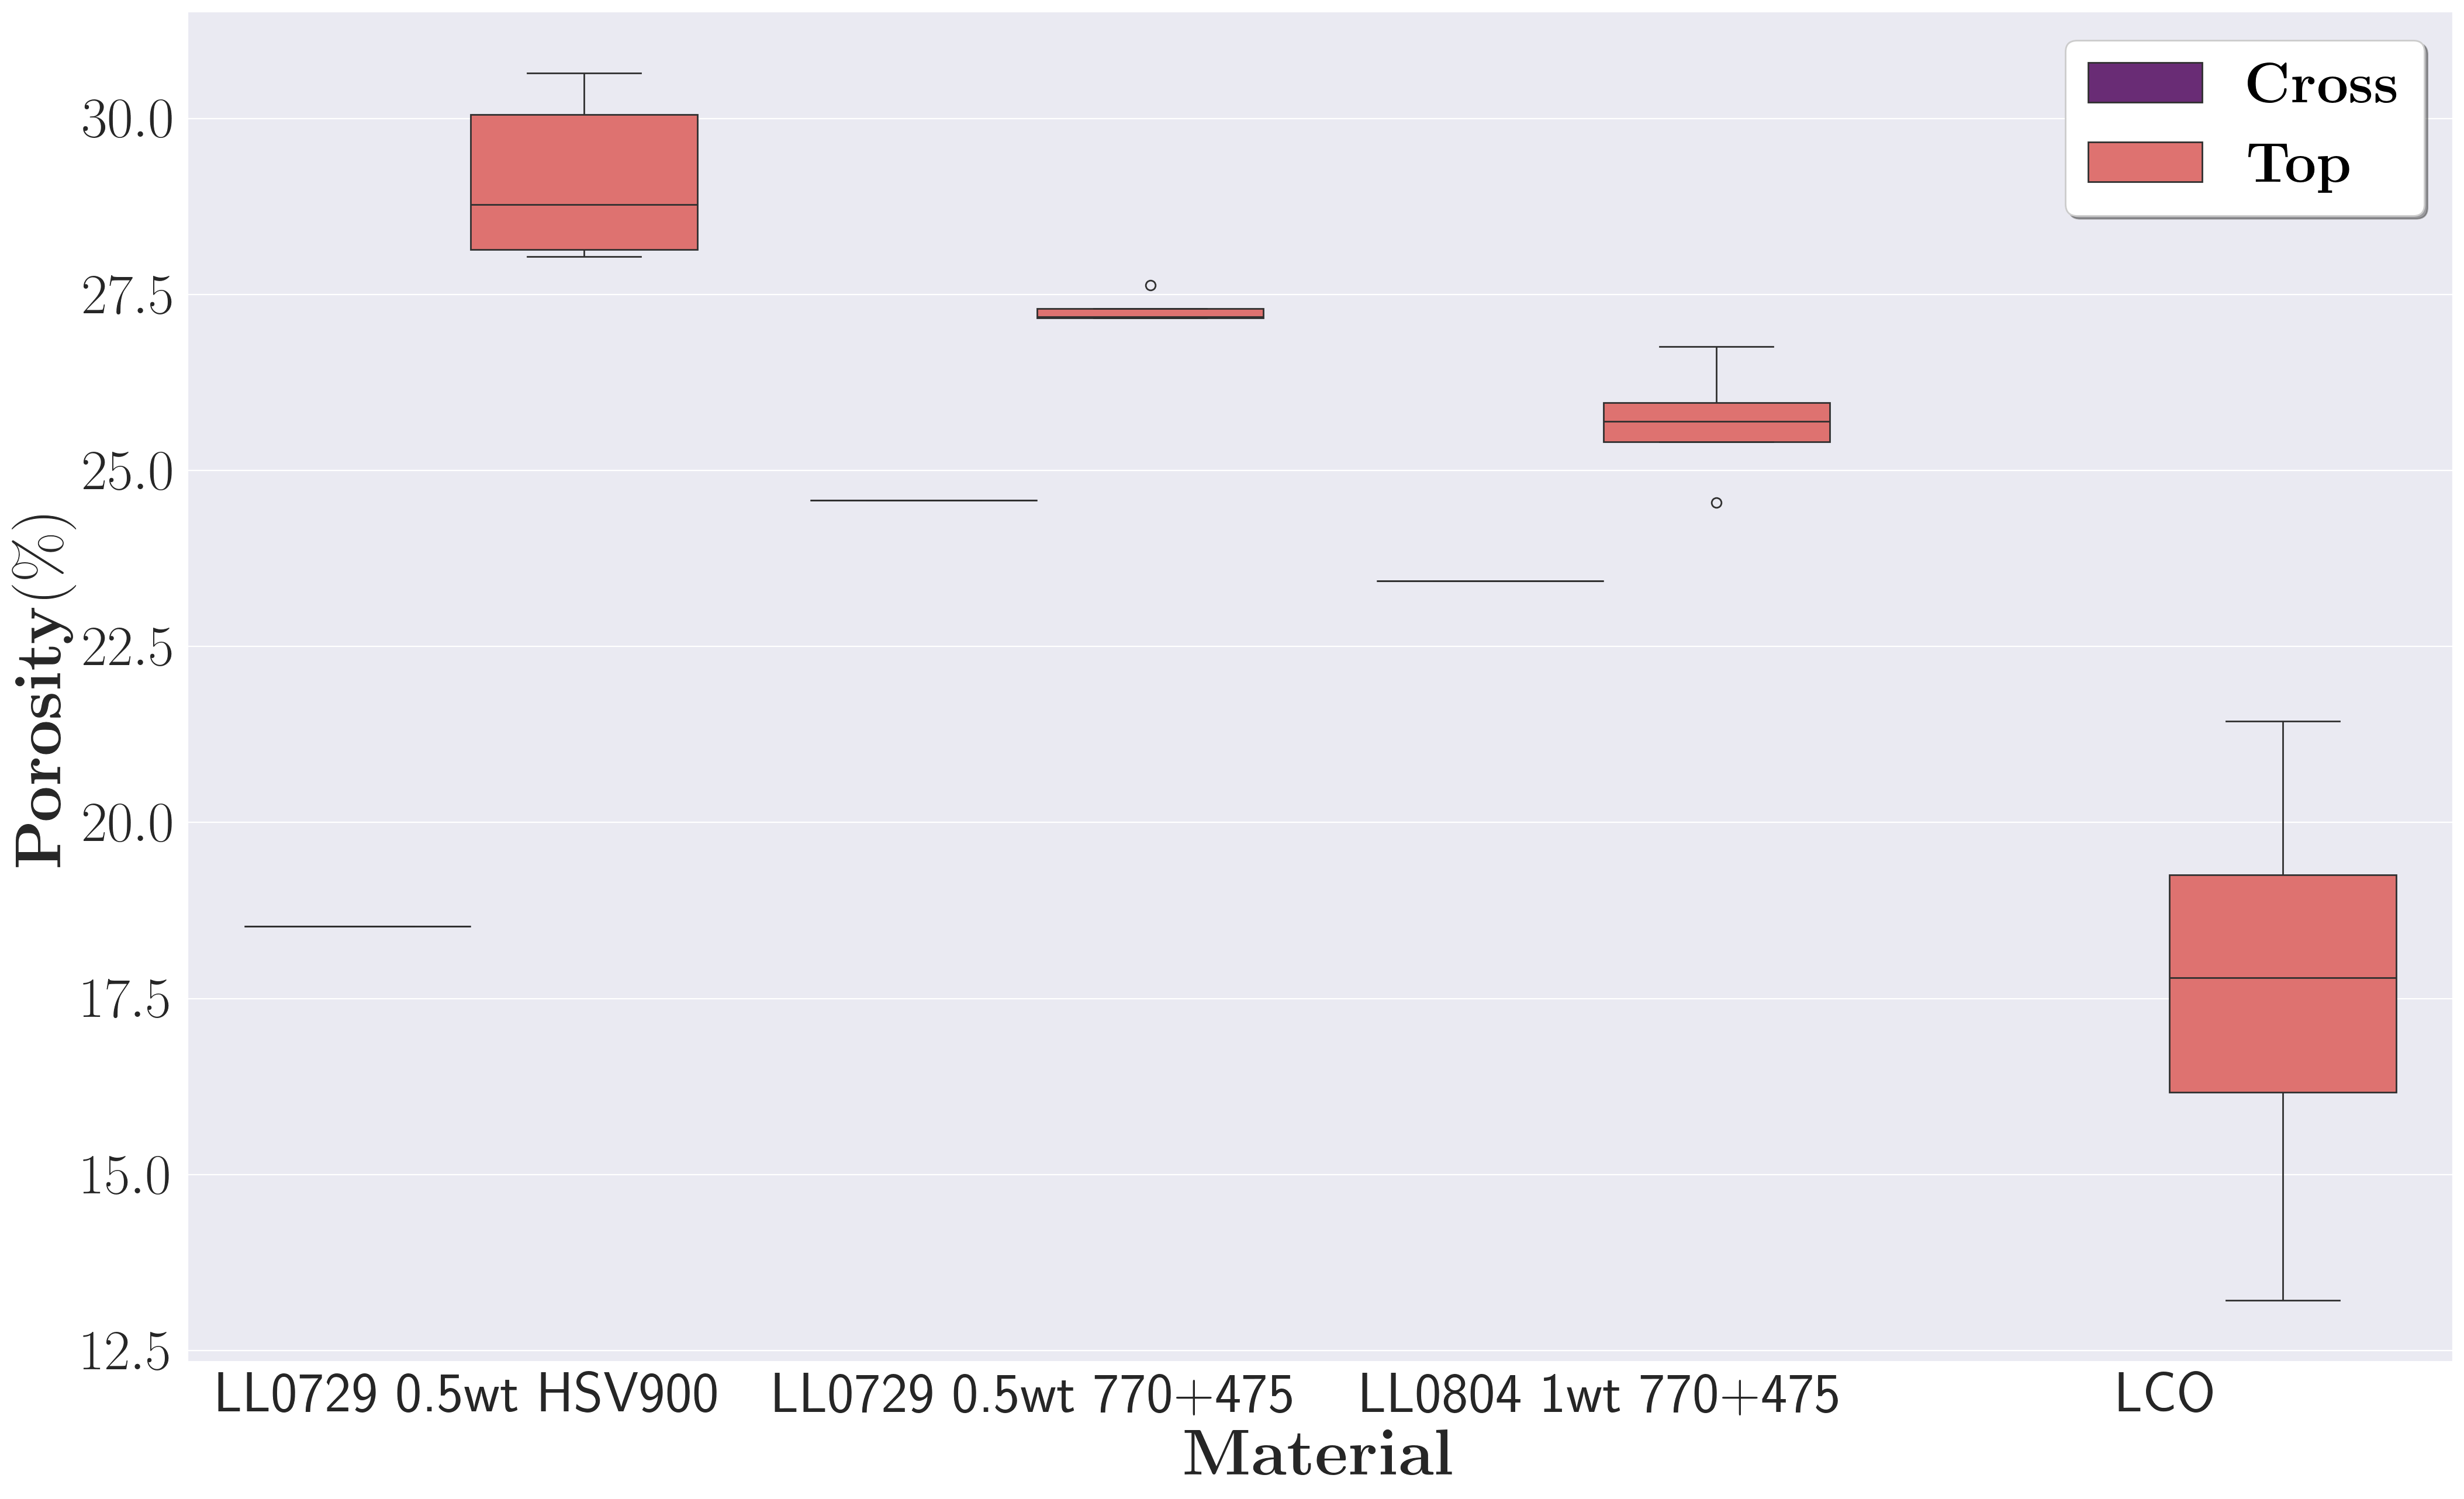

In [32]:
ax = start_plot(style="darkgrid", dpi=200, figsize=(25, 15))

sns.boxplot(data=df, x="Material", y="porosity", gap=2, hue="Position", palette="magma")

plt.ylabel(rf"$\bf Porosity (\%)$", fontsize=40)
plt.xlabel(rf"$\bf Material $", fontsize=40)
plt.yticks(fontsize=35)
plt.xticks(fontsize=35)
ax.legend(shadow=True, fontsize=35)
plt.show()

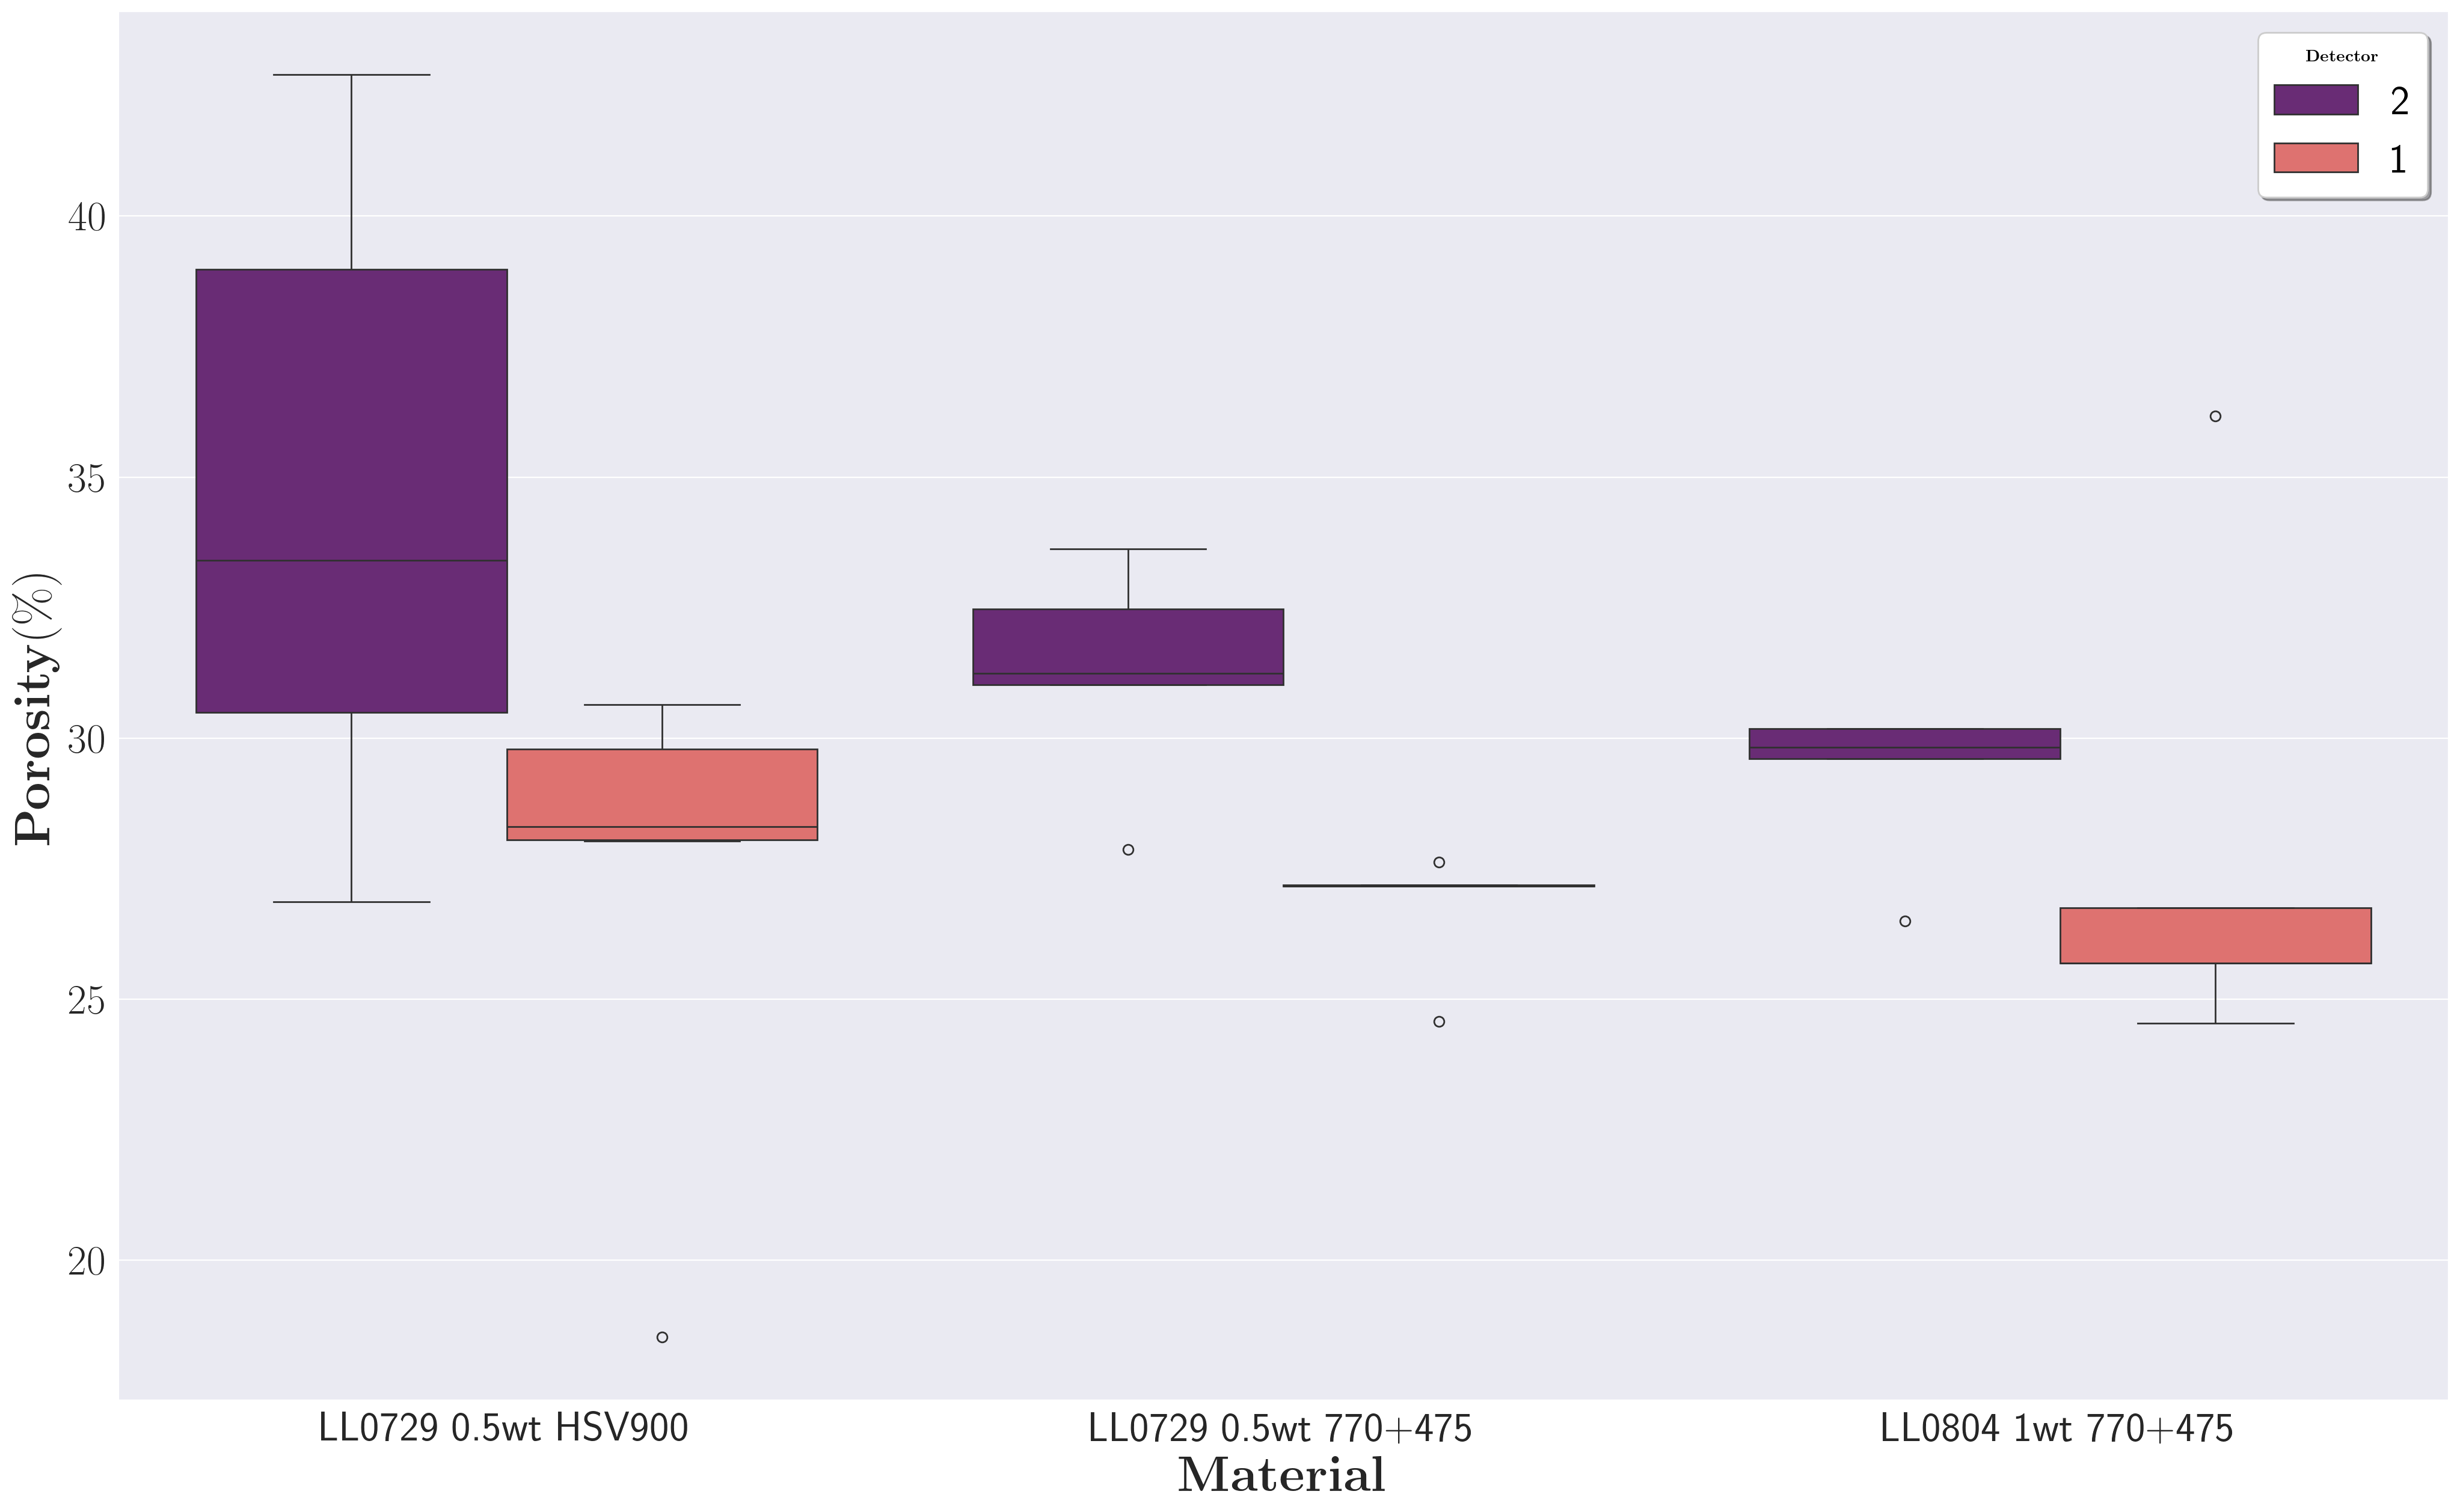

In [71]:
ax = start_plot(style="darkgrid", dpi=200, figsize=(25, 15))

sns.boxplot(data=df1, x="Material", y="porosity", gap=2, hue="Detector", palette="magma")

plt.ylabel(rf"$\bf Porosity (\%)$", fontsize=30)
plt.xlabel(rf"$\bf Material $", fontsize=30)
plt.yticks(fontsize=25)
plt.xticks(fontsize=25)
ax.legend(title=rf"$\bf Detector$", shadow=True, fontsize=25)
plt.show()